In [73]:
import xmltodict
import requests
import pandas as pd
import time
import math

# 1. API 설정
api_key = "663c9e65449b13834dbba27c3cd63d6449181fee65c69ff348dc4c41fc959e42"
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"

# 2. 먼저 1페이지 호출해서 totalCount 확인
params = {
    'serviceKey': api_key,
    'numOfRows': '10',
    'pageNo': '1',
    'zcode': '29'   # 서울, 전국이면 이 줄 제거
}

response = requests.get(url, params=params)
dict_data = xmltodict.parse(response.content)

# totalCount는 body 안에 있음
total_count = int(dict_data['response']['header']['totalCount'])
print(f'서울 지역 총 충전기 개수: {total_count}')

# 3. 페이지 수 계산
num_of_rows = 5000
total_pages = math.ceil(total_count / num_of_rows)
print(f'총 호출할 페이지 수: {total_pages}페이지 (1페이지 당 {num_of_rows}개씩)')

# 4. 전체 데이터 수집
all_items = []

for page in range(1, total_pages + 1):
    print(f'[{page}/{total_pages}] 페이지 수집 중...')

    params = {
        'serviceKey': api_key,
        'numOfRows': str(num_of_rows),
        'pageNo': str(page),
        'zcode': '29'   # 서울, 전국이면 이 줄 제거
    }

    try:
        res = requests.get(url, params=params)
        data = xmltodict.parse(res.content)

        items = data['response']['body'].get('items', {}).get('item', [])

        if isinstance(items, dict):
            all_items.append(items)
        else:
            all_items.extend(items)

    except Exception as e:
        print(f'오류 발생 ({page}페이지): {e}')

    time.sleep(1)

print('모든 데이터 수집 완료!!')

df_all = pd.DataFrame(all_items)

print(f'최종 데이터 크기 : {df_all.shape}')

df_all.to_csv('gj_data.csv', index=False, encoding='utf-8-sig')
print('gj_data.csv 파일로 저장됨.')

서울 지역 총 충전기 개수: 14490
총 호출할 페이지 수: 3페이지 (1페이지 당 5000개씩)
[1/3] 페이지 수집 중...
[2/3] 페이지 수집 중...
[3/3] 페이지 수집 중...
모든 데이터 수집 완료!!
최종 데이터 크기 : (14490, 37)
gj_data.csv 파일로 저장됨.


In [93]:
df_all = pd.read_csv('gj_data.csv', encoding='utf-8-sig', low_memory=False)
df_all.shape

(14490, 37)

In [94]:
df = df_all[['statNm', 'chgerType', 'addr', 'useTime', 'year', 'stat' , 'parkingFree','kind']]
df

,statNm,chgerType,addr,useTime,year,stat,parkingFree,kind
0,한국광기술원,6,광주광역시 북구 첨단 벤처로 108번길 9,24시간 이용가능,2018,2,Y,A0
1,롯데마트 수완점,6,광주광역시 광산구 장신로 98,10:00~23:00,2018,2,Y,E0
2,롯데마트 수완점,6,광주광역시 광산구 장신로 98,10:00~23:00,2018,2,Y,E0
3,블루핸즈 하남현대자동차서비스,6,광주광역시 광산구 하남대로 127-10,24시간 이용가능,2018,2,Y,F0
4,기아자동차 진월점,6,광주광역시 남구 진월동 314-1,24시간 이용가능,2018,2,Y,F0
...,...,...,...,...,...,...,...,...
14485,광주 서구 그랑빌더포레1(11kW),2,광주광역시 서구 개금길 77-4,24시간 이용가능,2023,2,N,G0
14486,광주 다나메디컬센터,2,광주광역시 서구 죽봉대로 68,시설 운영시간,2026,2,N,I0
14487,광주 다나메디컬센터,2,광주광역시 서구 죽봉대로 68,시설 운영시간,2026,3,N,I0
14488,(완속)농협-북광주본촌점,2,광주광역시 북구 하서로 563,24시간 이용가능,2023,2,Y,E0


In [95]:
df = df.rename(columns={
    'statNm': '충전소명',
    'chgerType': '충전기타입',
    'addr': '주소',
    'useTime': '이용가능시간',
    'year' : '제작년도',
    'stat' : '충전기상태',
    'parkingFree' : '무료주차',
    'kind' : '시설유형'
})

df

,충전소명,충전기타입,주소,이용가능시간,제작년도,충전기상태,무료주차,시설유형
0,한국광기술원,6,광주광역시 북구 첨단 벤처로 108번길 9,24시간 이용가능,2018,2,Y,A0
1,롯데마트 수완점,6,광주광역시 광산구 장신로 98,10:00~23:00,2018,2,Y,E0
2,롯데마트 수완점,6,광주광역시 광산구 장신로 98,10:00~23:00,2018,2,Y,E0
3,블루핸즈 하남현대자동차서비스,6,광주광역시 광산구 하남대로 127-10,24시간 이용가능,2018,2,Y,F0
4,기아자동차 진월점,6,광주광역시 남구 진월동 314-1,24시간 이용가능,2018,2,Y,F0
...,...,...,...,...,...,...,...,...
14485,광주 서구 그랑빌더포레1(11kW),2,광주광역시 서구 개금길 77-4,24시간 이용가능,2023,2,N,G0
14486,광주 다나메디컬센터,2,광주광역시 서구 죽봉대로 68,시설 운영시간,2026,2,N,I0
14487,광주 다나메디컬센터,2,광주광역시 서구 죽봉대로 68,시설 운영시간,2026,3,N,I0
14488,(완속)농협-북광주본촌점,2,광주광역시 북구 하서로 563,24시간 이용가능,2023,2,Y,E0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14490 entries, 0 to 14489
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   충전소명    14490 non-null  object
 1   충전기타입   14490 non-null  int64 
 2   주소      14490 non-null  object
 3   이용가능시간  14320 non-null  object
 4   제작년도    14490 non-null  int64 
 5   충전기상태   14490 non-null  int64 
 6   무료주차    14490 non-null  object
 7   시설유형    14485 non-null  object
dtypes: int64(3), object(5)
memory usage: 905.8+ KB


In [59]:
# 4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

# ** 특성공학
# 1. 주소 데이터에서 '시/도' 파생 변수 생성
# # 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df['시/도'] = df['주소'].str.split().str[1]
df
# # 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# # 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
df['시/도'] = df['시/도'].str[:3]
df
# 2. 충전기 타입 범주화
# # API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
df['충전기상태'] = df['충전기상태'].map({
    0 : '알수없음',
    1 : '통신이상',
    2 : '사용가능',
    3 : '충전중',
    4 : '운영중지',
    5 : '점검중'  
})
df


df['충전기타입기능'] = df['충전기타입'].map({
    1 : '완속',
    3 : '급속',
    6 : '초급속'
}).fillna('기타')
df
# 3. 24시간 이용 가능 여부 파생 변수 생성
# # 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
df['24시간가능'] = df['이용가능시간'].str[:4] == '24시간'
df

# ** 시각화
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)

# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)

# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

# ** 도출 인사이트

,충전소명,충전기타입,주소,이용가능시간,제작년도,충전기상태,무료주차,시/도,충전기타입기능,24시간가능
0,낙성대동주민센터,6,서울특별시 관악구 낙성대로4가길 5,24시간 이용가능,2017,사용가능,Y,관악구,초급속,True
1,서울추모공원,6,서울특별시 서초구 양재대로12길 74,24시간 이용가능,2017,충전중,N,서초구,초급속,True
2,롯데마트 송파점,6,서울특별시 송파구 중대로 80,24시간 이용가능,2017,사용가능,N,송파구,초급속,True
3,현대자동차 수색대리점,6,서울특별시 은평구 수색로 342-1,24시간 이용가능,2017,사용가능,N,은평구,초급속,True
4,태화빌딩,6,서울특별시 종로구 인사동5길 29,24시간 이용가능,2017,사용가능,N,종로구,초급속,True
...,...,...,...,...,...,...,...,...,...,...
71780,종로 한덕빌딩,2,서울특별시 종로구 종로41길 25,시설 운영 시간,2025,사용가능,N,종로구,기타,False
71781,이브이모드코리아,2,서울특별시 구로구 디지털로33길 27,24시간 이용가능,2025,사용가능,N,구로구,기타,True
71782,대륭포스트타워 1차,2,서울특별시 구로구 디지털로 288,24시간 이용가능,2024,충전중,N,구로구,기타,True
71783,강남아르누보씨티 호텔_서초,2,서울특별시 서초구 서초대로74길 49,24시간 이용가능,2025,충전중,N,서초구,기타,True


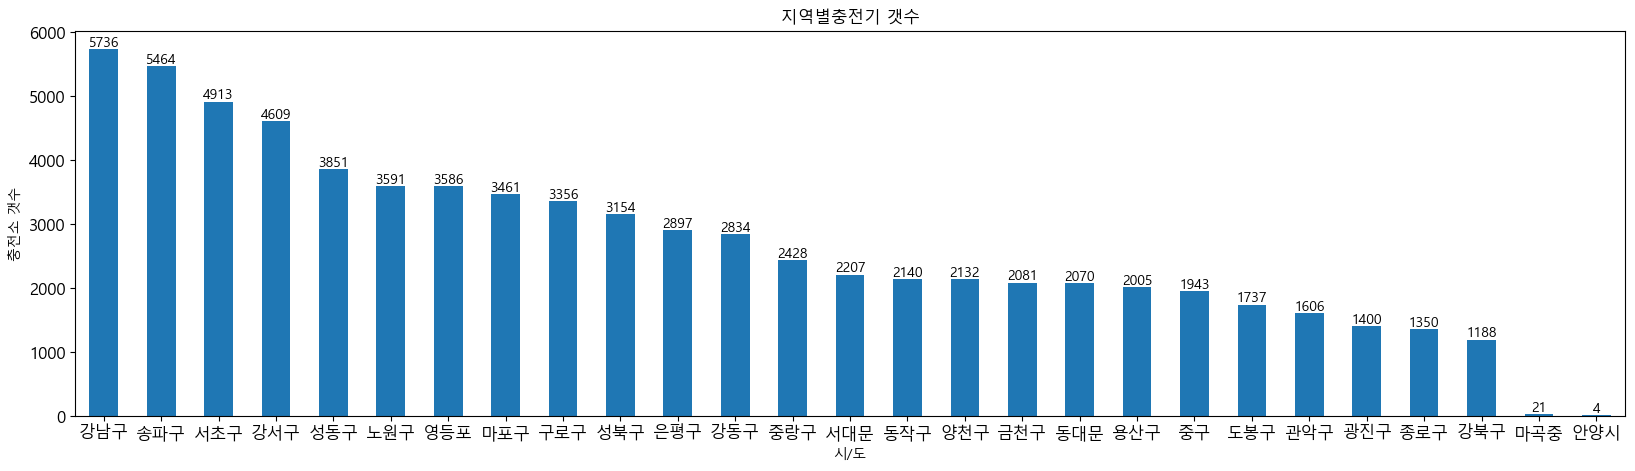

In [82]:
지역별충전기갯수 = df.groupby('시/도')['충전소명'].count().sort_values(ascending=False)
지역별충전기갯수
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


지역별충전기갯수.plot(kind='bar', figsize=(20,5), fontsize=12)
plt.title('지역별충전기 갯수')
plt.ylabel('충전소 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [86]:
지역별무료주차현황 = df.groupby(['시/도','무료주차'])['충전소명'].size().unstack()
지역별무료주차현황

무료주차,N,Y
시/도,,
강남구,2799.0,2936.0
강동구,1280.0,1554.0
강북구,499.0,685.0
강서구,2117.0,2492.0
관악구,912.0,694.0
광진구,595.0,805.0
구로구,1607.0,1746.0
금천구,1134.0,947.0
노원구,1483.0,2107.0


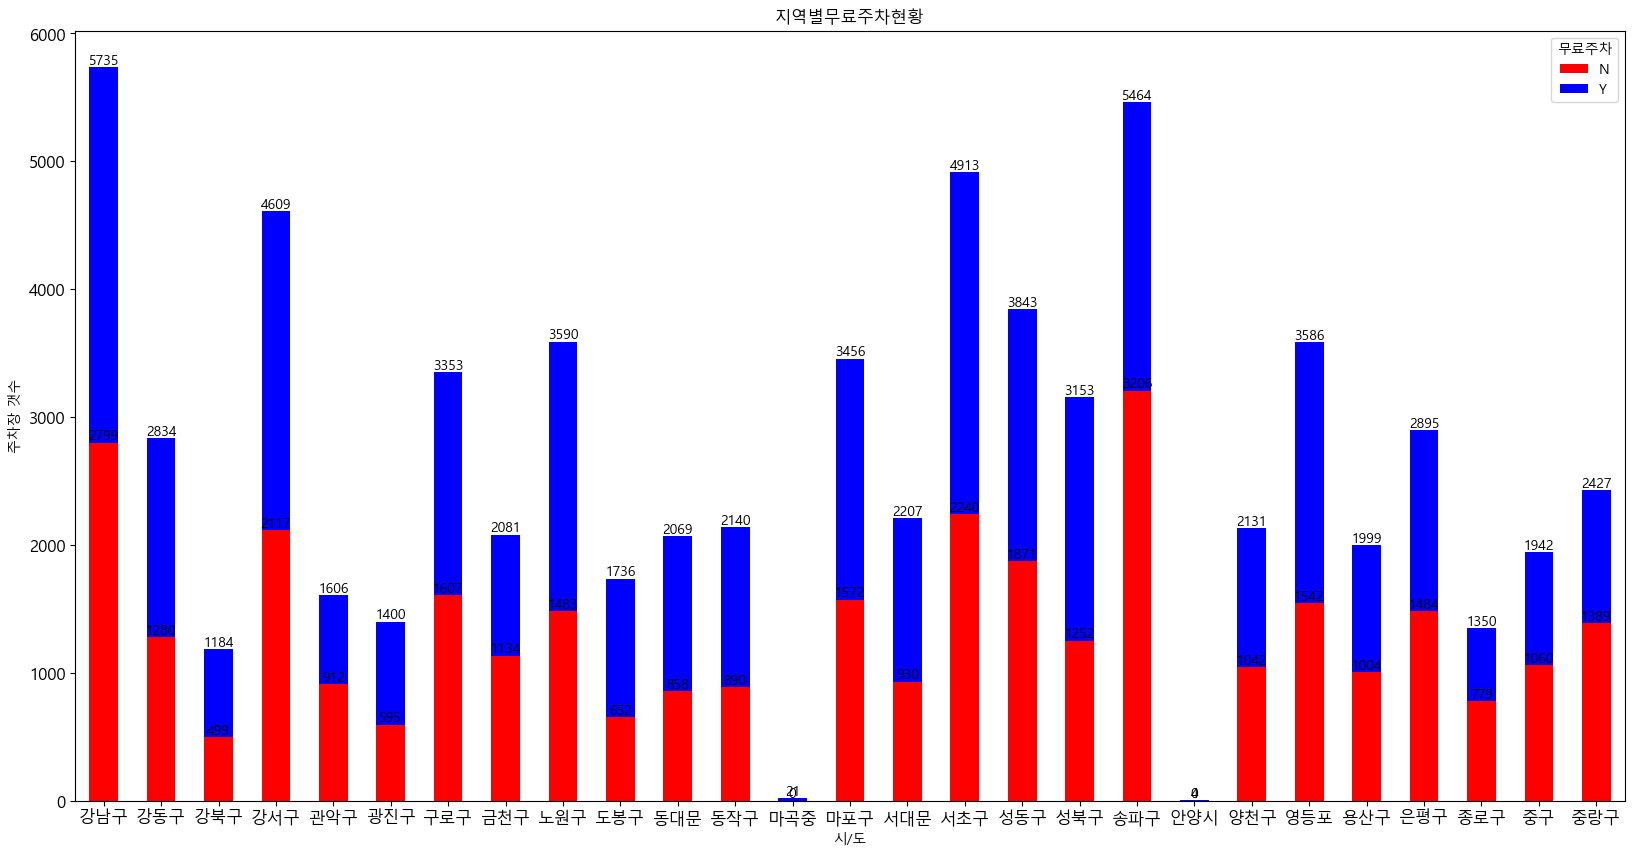

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


지역별무료주차현황.plot(kind='bar', stacked=True, figsize=(20,10), fontsize=12, color=['red','blue'])
plt.title('지역별무료주차현황')
plt.ylabel('주차장 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [89]:
충전기상태별현황 = df.groupby('충전기상태')['충전소명'].count().sort_values(ascending=False)
충전기상태별현황

충전기상태
사용가능    58027
충전중      9582
통신이상     1340
점검중       209
운영중지      103
Name: 충전소명, dtype: int64

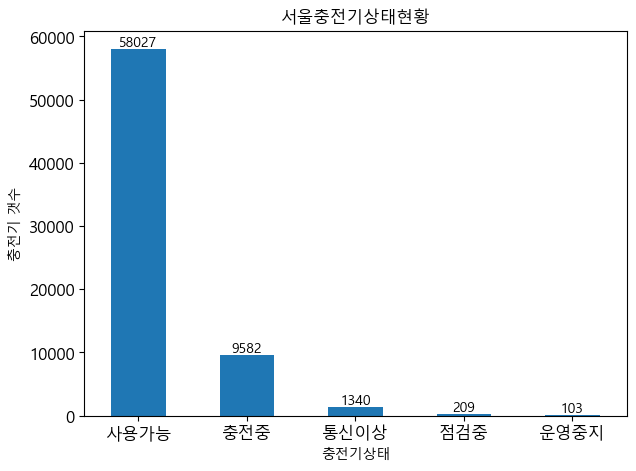

In [90]:
충전기상태별현황.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('서울충전기상태현황')
plt.ylabel('충전기 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

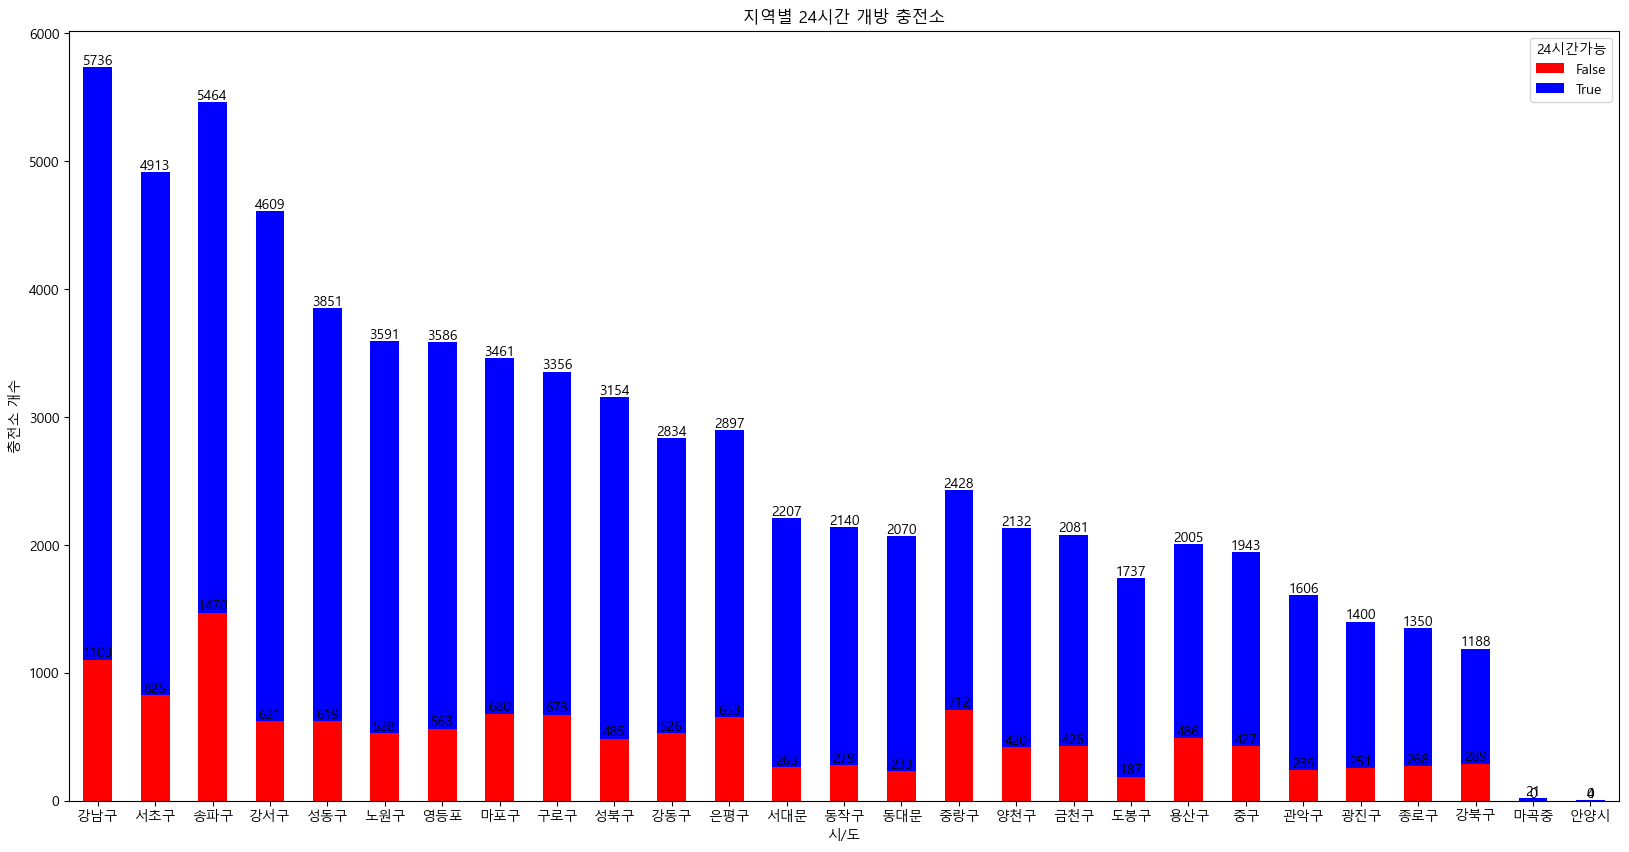

In [92]:
서울24 = df.groupby(['시/도','24시간가능']).size().unstack()

서울24 = 서울24.sort_values(by=True, ascending=False)

서울24.plot(kind='bar', stacked=True, color=['red','blue'], figsize=(20,10))

plt.title('지역별 24시간 개방 충전소')
plt.ylabel('충전소 개수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

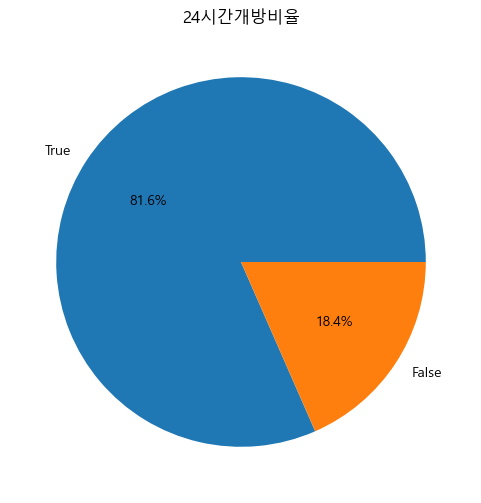

In [77]:
시간개방비율 = df['24시간가능'].value_counts()

시간개방비율.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title('24시간개방비율')
plt.ylabel('')

plt.show()

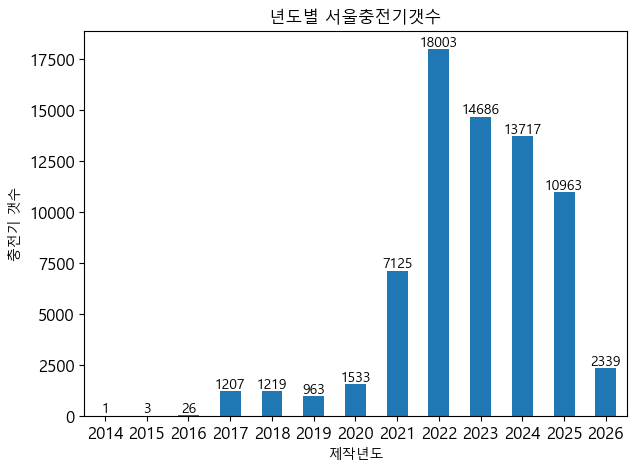

In [80]:
년도별충전소갯수 = df.groupby('제작년도')['충전소명'].count()
년도별충전소갯수
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


년도별충전소갯수.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('년도별 서울충전기갯수')
plt.ylabel('충전기 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [106]:
시설유형별충전기갯수 = df.groupby('시설유형')['충전소명'].count().sort_values(ascending=False)
시설유형별충전기갯수

시설유형
H0    11379
G0      827
E0      537
J0      458
A0      445
B0      409
I0      258
D0       87
F0       85
Name: 충전소명, dtype: int64

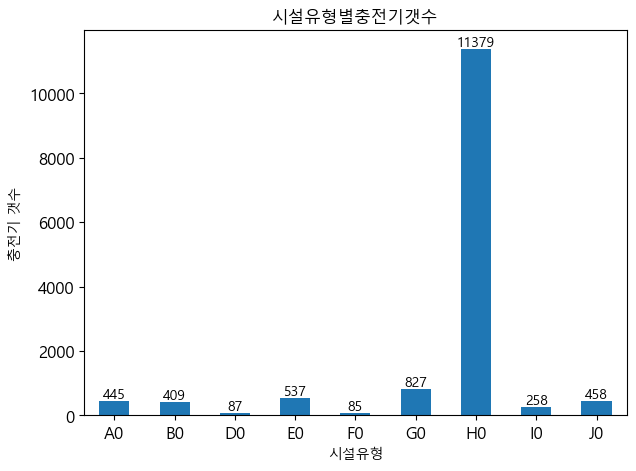

In [108]:

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


시설유형별충전소갯수.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('시설유형별충전기갯수')
plt.ylabel('충전기 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [109]:
df.groupby('시설유형').size()

시설유형
A0      445
B0      409
D0       87
E0      537
F0       85
G0      827
H0    11379
I0      258
J0      458
dtype: int64